# Introduction

Notebook ini berisi modeling untuk forecast perubahan harga menggunakan LightGBM. Data yang digunakan adalah data time-series yang berasal dari pangoly.com.

# Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime as dt
import joblib

from pathlib import Path

from sklearn.metrics import mean_absolute_error, mean_squared_error

import lightgbm as lgb
from lightgbm import LGBMRegressor

# Data Loading

In [2]:
file_path = Path('../data/pangoly.csv')
data = pd.read_csv(file_path)

In [3]:
data.dtypes

date         object
avg         float64
min         float64
max         float64
category     object
product      object
dtype: object

In [4]:
data['date'] = pd.to_datetime(data['date'])

# Exploratory Data Analysis

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 239295 entries, 0 to 239294
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   date      239295 non-null  datetime64[ns]
 1   avg       239295 non-null  float64       
 2   min       239295 non-null  float64       
 3   max       239295 non-null  float64       
 4   category  239295 non-null  object        
 5   product   239295 non-null  object        
dtypes: datetime64[ns](1), float64(3), object(2)
memory usage: 11.0+ MB


In [6]:
data.describe()

,date,avg,min,max
count,239295,239295.000000,239295.000000,239295.000000
mean,2024-05-12 18:51:01.703755008,307.536714,186.585464,493.107094
min,2021-08-24 00:00:00,18.990000,2.630000,24.990000
25%,2023-03-09 00:00:00,104.860000,49.990000,182.390000
50%,2024-06-19 00:00:00,190.460000,99.000000,316.250000
75%,2025-08-07 00:00:00,322.270000,194.260000,539.280000
max,2026-08-25 00:00:00,6325.820000,4099.990000,13603.260000
std,NaN,451.020856,290.014801,767.654127


In [7]:
data['category'].unique()

array(['MOTHERBOARDS', 'PROCESSORS', 'MEMORY', 'GRAPHICS CARDS',
       'POWER SUPPLIES', 'CASES', 'SOLID STATE DRIVES',
       'HARD DISK DRIVES', 'MONITORS', 'CPU COOLERS'], dtype=object)

In [8]:
len(data[data['category'] == 'PROCESSORS'])

31735

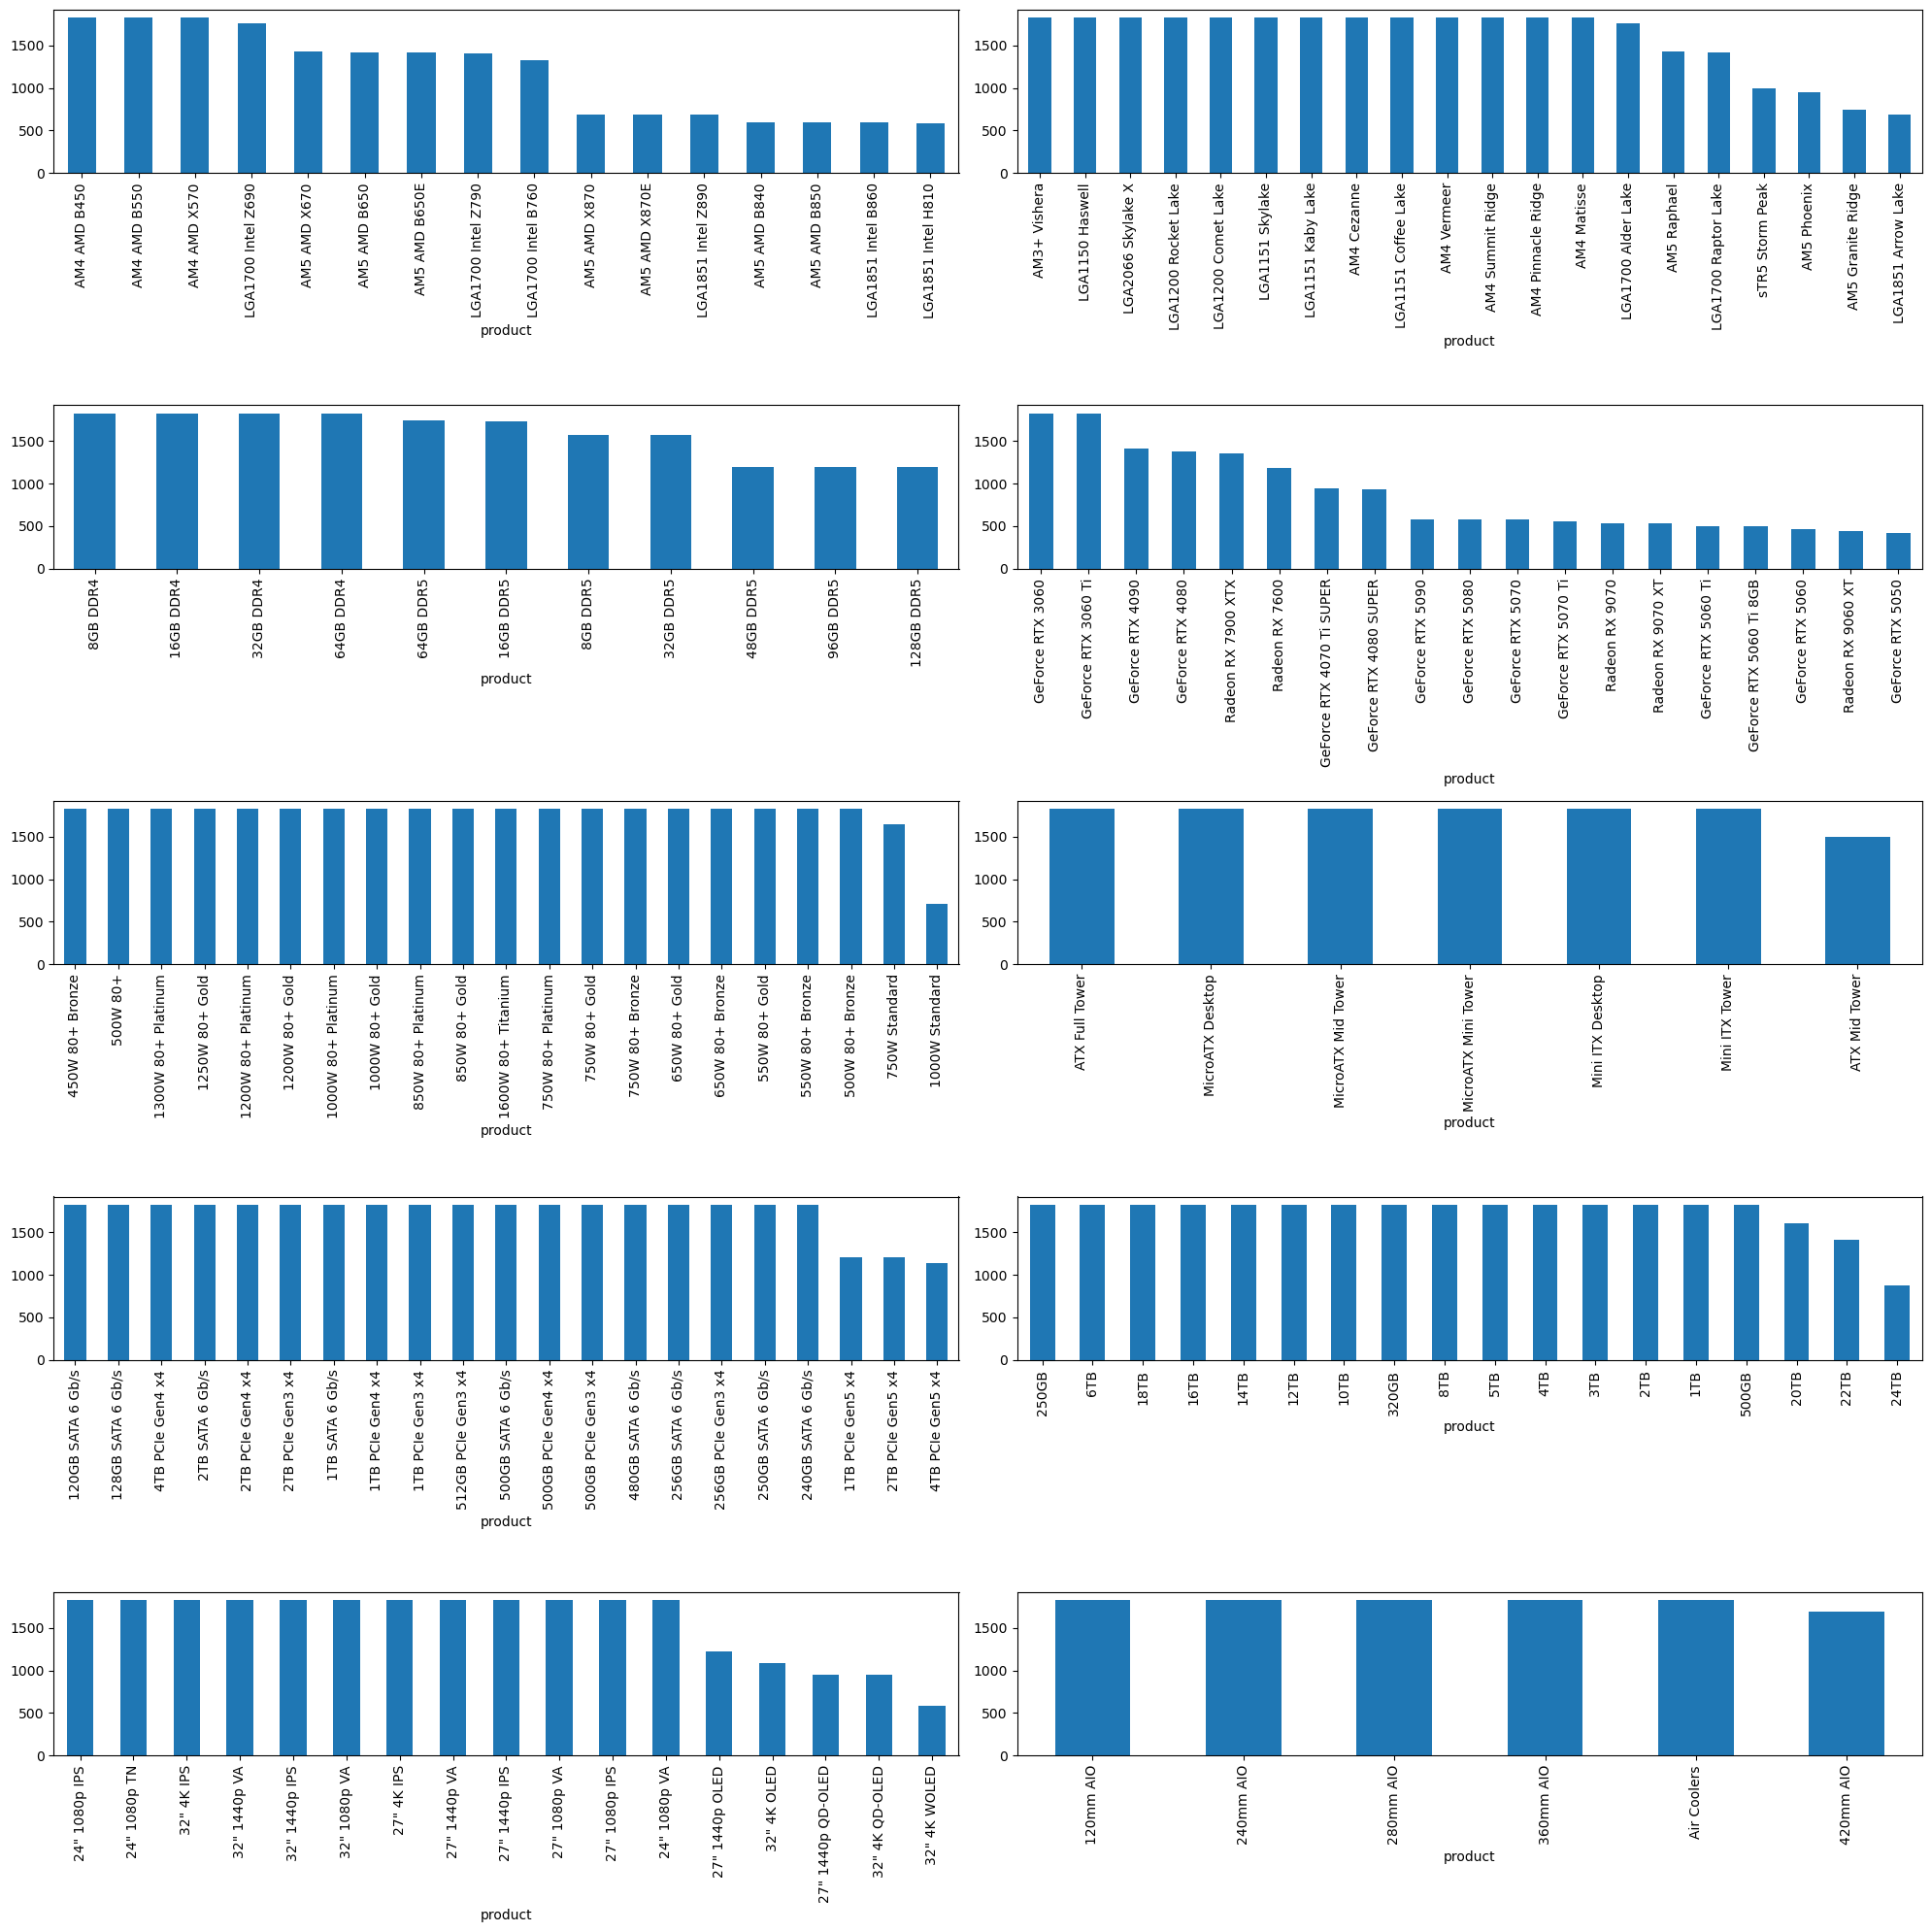

In [9]:
ncols = 2
nrows = 5
fig, axs = plt.subplots(ncols=ncols, nrows=nrows, figsize=(20, 20))
axes = axs.flatten()

for i, category in enumerate(list(data['category'].unique())):
    data_cat = data[data['category'] == category]
    data_cat['product'].value_counts().plot(kind='bar', ax=axes[i])

plt.tight_layout()

In [10]:
for i, category in enumerate(list(data['category'].unique())):
    data_cat = data[data['category'] == category]
    print(category, 'number of unique product group: ', data_cat['product'].nunique())

MOTHERBOARDS number of unique product group:  16
PROCESSORS number of unique product group:  20
MEMORY number of unique product group:  11
GRAPHICS CARDS number of unique product group:  19
POWER SUPPLIES number of unique product group:  21
CASES number of unique product group:  7
SOLID STATE DRIVES number of unique product group:  21
HARD DISK DRIVES number of unique product group:  18
MONITORS number of unique product group:  17
CPU COOLERS number of unique product group:  6


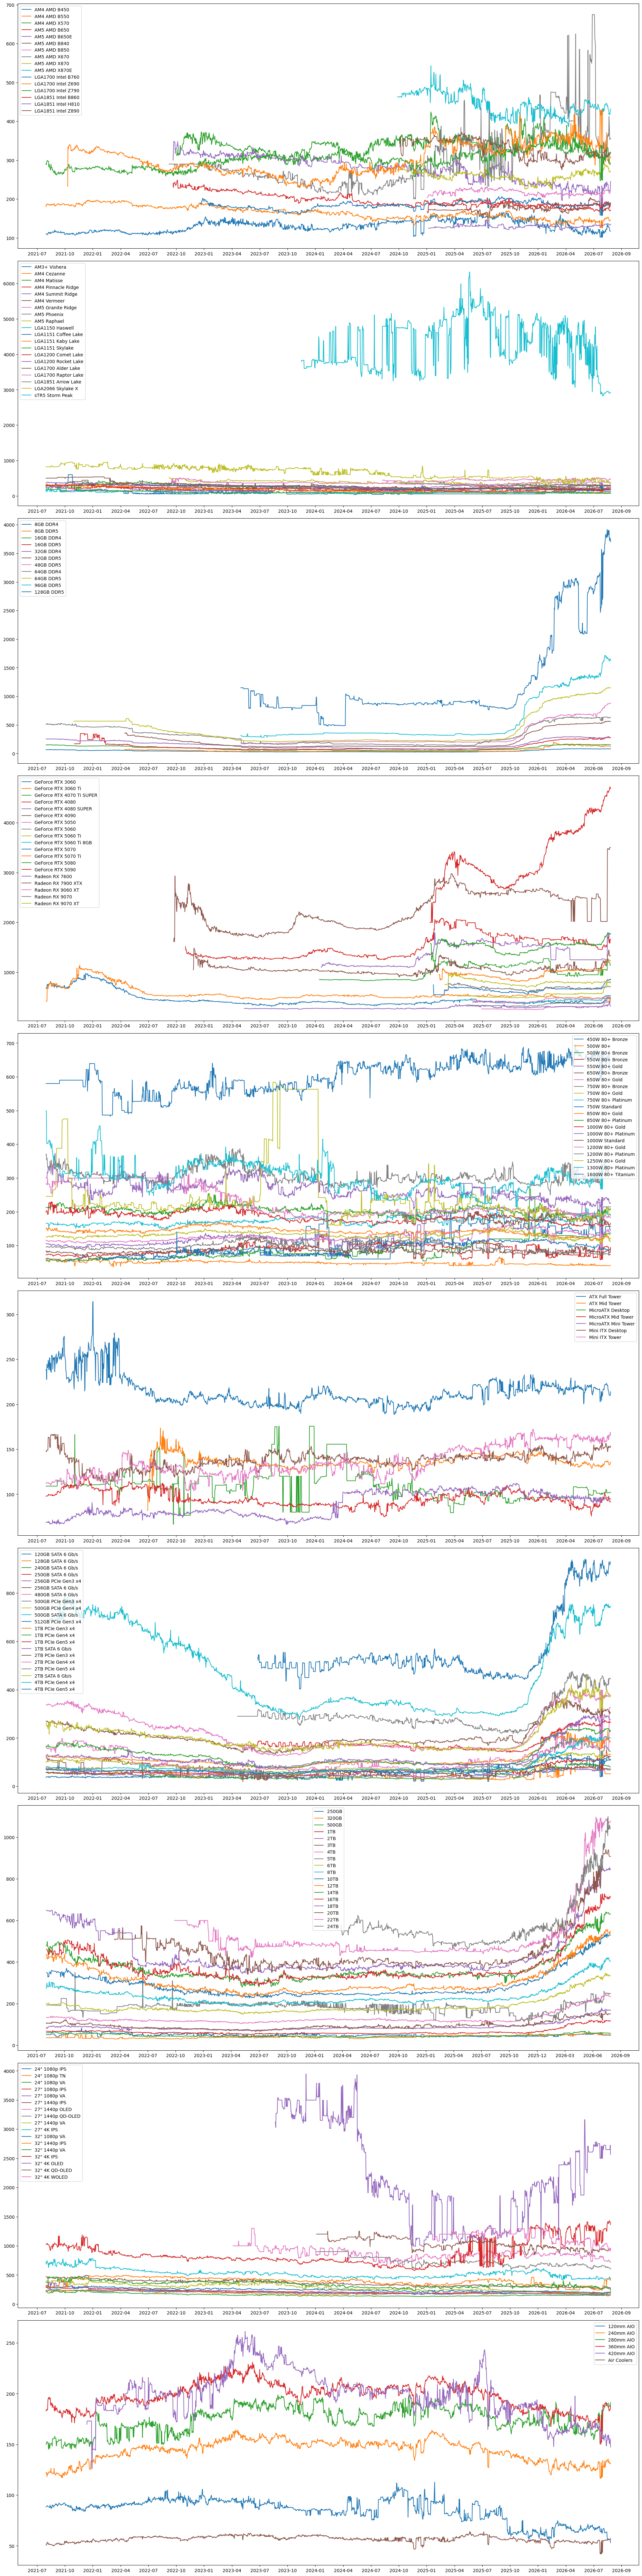

In [11]:
ncols = 1
nrows = 10
fig, axs = plt.subplots(ncols=ncols, nrows=nrows, figsize=(20, 80))
axes = axs.flatten()

for i, category in enumerate(list(data['category'].unique())):
    data_cat = data[data['category'] == category]
    for group in data_cat['product'].unique():
        data_group = data_cat[data_cat['product'] == group]
        axes[i].plot(data_group['date'], data_group['avg'], label=group)

    axes[i].xaxis.set_major_locator(mdates.DayLocator(interval=90))
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    axes[i].legend()


plt.tight_layout()

# Feature Engineering

Only CPU, GPU, Memory

In [12]:
selected_cats = ['PROCESSORS', 'GRAPHICS CARDS', 'MEMORY', 'SOLID STATE DRIVES']

In [13]:
df = data[data['category'].isin(selected_cats)].copy()
len(df)

102247

In [14]:
df.columns

Index(['date', 'avg', 'min', 'max', 'category', 'product'], dtype='object')

In [15]:
def prepare_df(raw: pd.DataFrame, lags: list = [1], rolling: list = []) -> pd.DataFrame:
    df = raw.copy()
    df = raw[['avg', 'date', 'product', 'category']].copy()
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values(by='date', ascending=True)

    for col in ['product', 'category']:
        df[col] = df[col].astype('category')

    df['day_of_week'] = df['date'].dt.dayofweek
    df['day_of_month'] = df['date'].dt.day
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)
    df['is_month_end'] = df['date'].dt.is_month_end.astype(int)
    
    for lag in lags:
        df[f'lag_{lag}d'] = df['avg'].shift(lag)

    for window in rolling:
        df[f'mean_{window}d'] = df['avg'].shift(1).rolling(window=window).mean()
        df[f'max_{window}d'] = df['avg'].shift(1).rolling(window=window).max()
        df[f'min_{window}d'] = df['avg'].shift(1).rolling(window=window).min()
        df[f'std_{window}d'] = df['avg'].shift(1).rolling(window=window).std()

    df['pct_change'] = ((df['avg'] - df['lag_1d'])/df['lag_1d'])*100

    df = df.dropna().reset_index(drop=True)

    return df

In [16]:
lags = [1,2,3,7,14,30]
rolling = [3, 7, 30]

dfs = []
for prod in df['product'].unique():
    prod_df = df[df['product'] == prod]
    prod_df = prepare_df(prod_df, lags=lags, rolling=rolling)
    dfs.append(prod_df)

df = pd.concat(dfs)
for col in ['product', 'category']:
    df[col] = df[col].astype('category')

In [17]:
df.dtypes

avg                    float64
date            datetime64[ns]
product               category
category              category
day_of_week              int32
day_of_month             int32
month                    int32
year                     int32
is_weekend               int64
is_month_end             int64
lag_1d                 float64
lag_2d                 float64
lag_3d                 float64
lag_7d                 float64
lag_14d                float64
lag_30d                float64
mean_3d                float64
max_3d                 float64
min_3d                 float64
std_3d                 float64
mean_7d                float64
max_7d                 float64
min_7d                 float64
std_7d                 float64
mean_30d               float64
max_30d                float64
min_30d                float64
std_30d                float64
pct_change             float64
dtype: object

# Train-Test Split

In [18]:
span = (df['date'].max() - df['date'].min()).days
test_days = dt.timedelta(days=span*0.1).days
cutoff_date = df['date'].max() - dt.timedelta(days=test_days)

In [19]:
df_train = df[df['date'] < cutoff_date]
df_test = df[df['date'] >= cutoff_date]

len(df_train), len(df_test)

(87367, 12750)

In [20]:
y_train = df_train['pct_change']
X_train = df_train.drop(columns=['pct_change', 'date', 'avg'])

y_test = df_test['pct_change']
X_test = df_test.drop(columns=['pct_change', 'date', 'avg'])

In [21]:
X_train.dtypes

product         category
category        category
day_of_week        int32
day_of_month       int32
month              int32
year               int32
is_weekend         int64
is_month_end       int64
lag_1d           float64
lag_2d           float64
lag_3d           float64
lag_7d           float64
lag_14d          float64
lag_30d          float64
mean_3d          float64
max_3d           float64
min_3d           float64
std_3d           float64
mean_7d          float64
max_7d           float64
min_7d           float64
std_7d           float64
mean_30d         float64
max_30d          float64
min_30d          float64
std_30d          float64
dtype: object

# Model Definition

In [22]:
lgb_model = LGBMRegressor(n_estimators=100, max_depth=5)

# Training

In [23]:
lgb_model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002782 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4729
[LightGBM] [Info] Number of data points in the train set: 87367, number of used features: 26
[LightGBM] [Info] Start training from score 0.140836
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

LGBMRegressor(max_depth=5)

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

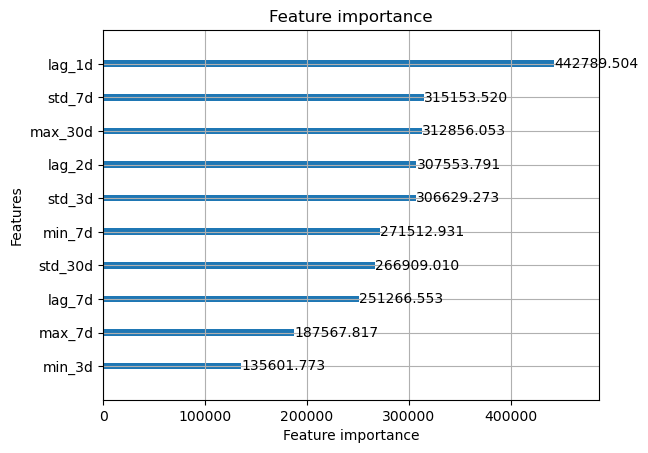

In [24]:
lgb.plot_importance(lgb_model, importance_type='gain', max_num_features=10)

# Evaluation

In [25]:
pred_test = lgb_model.predict(X_test)

In [26]:
mae = mean_absolute_error(y_test, pred_test)
rmse = np.sqrt(mean_squared_error(y_test, pred_test))

mae, rmse

(2.436972618101272, 6.087396855235606)

# Predict

In [27]:
def predict(steps: int, product: str):
    df_prod_original = df[df['product'] == product]

    df_prod = df_prod_original.copy()
    df_prod = df_prod.sort_values(by=['date'], ascending=True)

    latest_known_date = df_prod['date'].max()
    cat = df_prod['category'][0]

    preds = []
    for _ in range(steps):
        new_date = latest_known_date + dt.timedelta(days=1)
        data = {
            'date': [new_date],
            'product': [product],
            'category': [cat]
        }
        current_df = pd.DataFrame(data)

        for col in ['product', 'category']:
            current_df[col] = current_df[col].astype('category')
        
        current_df['day_of_week'] = current_df['date'].dt.dayofweek
        current_df['day_of_month'] = current_df['date'].dt.day
        current_df['month'] = current_df['date'].dt.month
        current_df['year'] = current_df['date'].dt.year
        current_df['is_weekend'] = current_df['day_of_week'].isin([5,6]).astype(int)
        current_df['is_month_end'] = current_df['date'].dt.is_month_end.astype(int)

        for lag in lags:
            current_df[f'lag_{lag}d'] = df_prod['avg'].iloc[-lag]

        for window in rolling:
            current_df[f'mean_{window}d'] = df_prod['avg'].iloc[-window:].mean()
            current_df[f'max_{window}d'] = df_prod['avg'].iloc[-window:].max()
            current_df[f'min_{window}d'] = df_prod['avg'].iloc[-window:].min()
            current_df[f'std_{window}d'] = df_prod['avg'].iloc[-window:].std()

        X = current_df.drop(columns=['date'])
        pred = lgb_model.predict(X)

        current_df['pct_change'] = pred
        current_df['avg'] = current_df['lag_1d'] * (1 + (pred/100))
        df_prod = pd.concat([df_prod, current_df])
        latest_known_date = df_prod['date'].max()
        preds.append(current_df)

    df_prod_original['is_pred'] = False
    df_preds = pd.concat(preds)
    df_preds['is_pred'] = True
    return pd.concat([df_prod_original, df_preds])

In [28]:
def plot_time_series(df1: pd.DataFrame, col: str, df2: pd.DataFrame = None, df1_label: str = 'data 1', df2_label: str = 'data 2', x_col: str = None):
    fig, ax = plt.subplots(figsize=(12, 7))

    x_1 = df1.index if x_col is None else df1[x_col]
    ax.plot(x_1, df1[col], color='blue', label=df1_label)

    if df2 is not None:
        x_2 = df2.index if x_col is None else df2[x_col]
        ax.plot(x_2, df2[col], color='orange', label=df2_label)

    plt.ylabel('Avg Price (USD)')
    plt.xlabel('Date')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [29]:
list(df['product'].unique())[:50]

['AM3+ Vishera',
 'AM4 Cezanne',
 'AM4 Matisse',
 'AM4 Pinnacle Ridge',
 'AM4 Summit Ridge',
 'AM4 Vermeer',
 'AM5 Granite Ridge',
 'AM5 Phoenix',
 'AM5 Raphael',
 'LGA1150 Haswell',
 'LGA1151 Coffee Lake',
 'LGA1151 Kaby Lake',
 'LGA1151 Skylake',
 'LGA1200 Comet Lake',
 'LGA1200 Rocket Lake',
 'LGA1700 Alder Lake',
 'LGA1700 Raptor Lake',
 'LGA1851 Arrow Lake',
 'LGA2066 Skylake X',
 'sTR5 Storm Peak',
 '8GB DDR4',
 '8GB DDR5',
 '16GB DDR4',
 '16GB DDR5',
 '32GB DDR4',
 '32GB DDR5',
 '48GB DDR5',
 '64GB DDR4',
 '64GB DDR5',
 '96GB DDR5',
 '128GB DDR5',
 'GeForce RTX 3060',
 'GeForce RTX 3060 Ti',
 'GeForce RTX 4070 Ti SUPER',
 'GeForce RTX 4080',
 'GeForce RTX 4080 SUPER',
 'GeForce RTX 4090',
 'GeForce RTX 5050',
 'GeForce RTX 5060',
 'GeForce RTX 5060 Ti',
 'GeForce RTX 5060 Ti 8GB',
 'GeForce RTX 5070',
 'GeForce RTX 5070 Ti',
 'GeForce RTX 5080',
 'GeForce RTX 5090',
 'Radeon RX 7600',
 'Radeon RX 7900 XTX',
 'Radeon RX 9060 XT',
 'Radeon RX 9070',
 'Radeon RX 9070 XT']

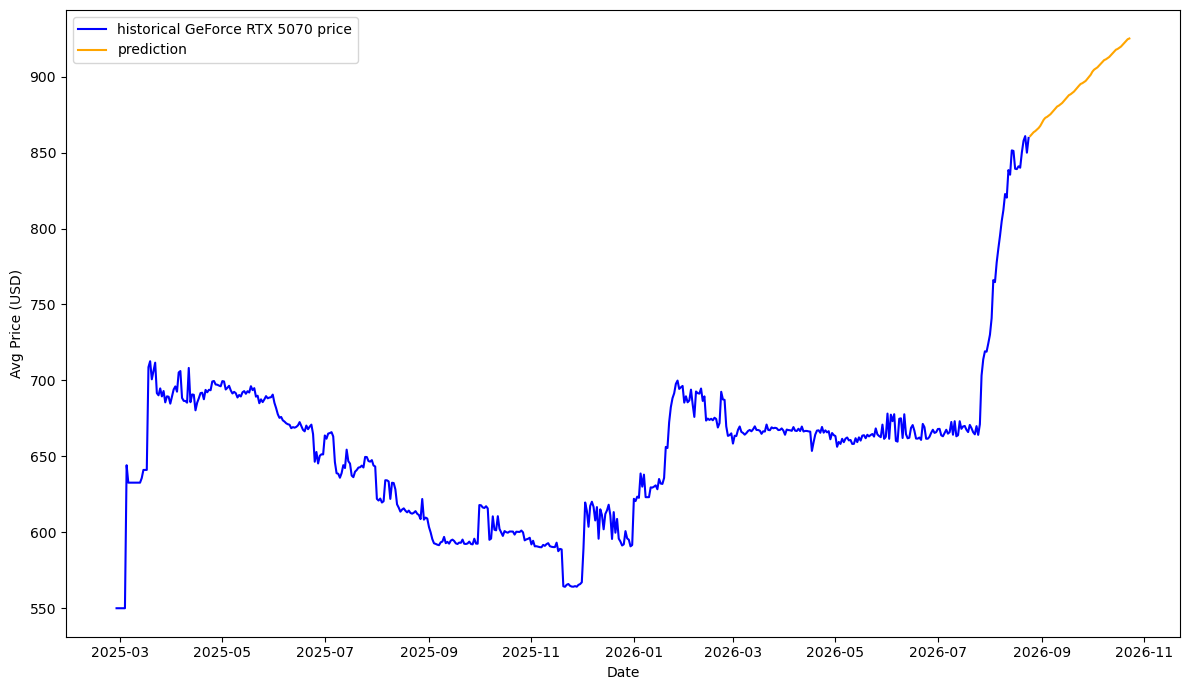

In [ ]:
product = 'GeForce RTX 5060 Ti'
steps = 60

pred = predict(steps, product)

ori_df = pred[pred['is_pred'] == False]
pred_df = pred[pred['is_pred'] == True]

plot_time_series(ori_df, 'avg', df2=pred_df, x_col='date', df1_label=f'historical {product} price', df2_label='prediction')

# Save Model

In [31]:
model_path = Path('../models/lgbm.joblib')
joblib.dump(lgb_model, model_path)

['../models/lgbm.joblib']